# ShelfSight — YOLOv8n & Augmentation Shelf Detection Model
### AI Lab Project | CSC-233 | BNU Spring 2026
**Student:** Saad Riaz (F2024-0543) | **Role:** Group Member + Model 3

---

## Before you start
1. Go to **Runtime → Change runtime type → T4 GPU → Save**
2. Make sure your Roboflow dataset is exported in **YOLOv8 format**
3. Run every cell **in order** from top to bottom

---

## Phase 1 — Setup and Installation

### Step 1 — Install YOLOv8
This installs the Ultralytics library which contains YOLOv8. Only needs to run once per session.

In [23]:
%pip install ultralytics roboflow --quiet
import ultralytics
ultralytics.checks()  # confirms GPU is active and version is correct

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 48.0/112.6 GB disk)


### Step 2 — Import libraries

In [24]:
import os
import shutil
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from ultralytics import YOLO
from PIL import Image

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Phase 2 — Download Dataset from Roboflow

> **Action needed:** Replace the code below with your actual Roboflow export snippet.
> Go to your Roboflow project → Versions → Export → YOLOv8 → Show download code → Copy and paste it here.

### Step 3 — Connect to Roboflow and download dataset

In [25]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="G2NmxkC2Za5dtJ47ID3a")
project = rf.workspace("rf20-vl").project("soda-bottles-haga")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [26]:
# ─── DATASET PATH FIX — run once after Roboflow download ─────────────────────
import yaml
from pathlib import Path

# Find data.yaml
yaml_files = list(Path(".").rglob("data.yaml"))
DATA_YAML  = yaml_files[0]
dataset_root = DATA_YAML.parent  # e.g. soda-bottles-haga-1/

print(f"data.yaml : {DATA_YAML}")
print(f"Dataset root: {dataset_root.resolve()}")

# Show what's actually in the folder
print("\nActual folder contents:")
for p in sorted(dataset_root.rglob("*"))[:40]:
    print(f"  {p}")

# Read current yaml
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)
print(f"\nCurrent yaml paths → train: {cfg.get('train')}  val: {cfg.get('val')}  test: {cfg.get('test')}")

# Auto-detect the real image folders
train_imgs = list(dataset_root.rglob("train/images"))
val_imgs   = list(dataset_root.rglob("valid/images")) or list(dataset_root.rglob("val/images"))
test_imgs  = list(dataset_root.rglob("test/images"))

if not train_imgs:
    print("\n❌ Still can't find train/images — paste the folder listing above and share it")
else:
    # Rewrite data.yaml with absolute paths
    cfg["train"] = str(train_imgs[0].resolve())
    cfg["val"]   = str(val_imgs[0].resolve())  if val_imgs  else cfg["val"]
    cfg["test"]  = str(test_imgs[0].resolve()) if test_imgs else cfg.get("test", "")

    with open(DATA_YAML, "w") as f:
        yaml.dump(cfg, f)

    print(f"\n✅ data.yaml rewritten with absolute paths:")
    print(f"   train : {cfg['train']}  ({len(list(Path(cfg['train']).glob('*.*')))} images)")
    print(f"   val   : {cfg['val']}  ({len(list(Path(cfg['val']).glob('*.*')))} images)")
    print(f"   test  : {cfg.get('test')}")
    print(f"\nNow re-run Step 9 (training) ✅")

data.yaml : soda-bottles-haga-1/data.yaml
Dataset root: /content/soda-bottles-haga-1

Actual folder contents:
  soda-bottles-haga-1/README.dataset.txt
  soda-bottles-haga-1/README.roboflow.txt
  soda-bottles-haga-1/data.yaml
  soda-bottles-haga-1/test
  soda-bottles-haga-1/test/images
  soda-bottles-haga-1/test/images/01_20220314_152250_bmp_jpg.rf.13a503eef2e257bb09624567a53d6fb4.jpg
  soda-bottles-haga-1/test/images/01_20220314_154710_bmp_jpg.rf.edf5dca811c8ac647991f06804fd0c7b.jpg
  soda-bottles-haga-1/test/images/01_20220314_155734_bmp_jpg.rf.c8dd61c98255fab7139f2e4ef50f4f65.jpg
  soda-bottles-haga-1/test/images/01_20220314_155901_bmp_jpg.rf.61e47a3f2fa737f0a312f360709ef669.jpg
  soda-bottles-haga-1/test/images/01_20220314_160735_bmp_jpg.rf.fa37d4616141fba11dd21b2d768e307a.jpg
  soda-bottles-haga-1/test/images/01_20220314_160915_bmp_jpg.rf.55ef3b626e2220df9b5fef2e9556bc96.jpg
  soda-bottles-haga-1/test/images/01_20220314_162815_bmp_jpg.rf.732dd42e700d44e5f950b779c26f6db4.jpg
  soda-

### Step 4 — Verify the dataset structure
Checks that images and labels are in the right folders.

In [27]:
# Find the data.yaml file (YOLOv8 needs this to know where your images are)
yaml_files = list(Path(".").rglob("data.yaml"))
if not yaml_files:
    raise FileNotFoundError("data.yaml not found. Check your Roboflow download.")

DATA_YAML = str(yaml_files[0])
print("data.yaml found at:", DATA_YAML)

# Read and display the yaml contents
with open(DATA_YAML, "r") as f:
    content = f.read()
print("\nDataset config:")
print(content)

data.yaml found at: soda-bottles-haga-1/data.yaml

Dataset config:
names:
- coca-cola
- fanta
- sprite
nc: 3
roboflow:
  license: MIT
  project: soda-bottles-haga
  url: https://universe.roboflow.com/rf20-vl/soda-bottles-haga/dataset/1
  version: 1
  workspace: rf20-vl
test: /content/soda-bottles-haga-1/test/images
train: /content/soda-bottles-haga-1/train/images
val: /content/soda-bottles-haga-1/valid/images



### Step 5 — Check class balance
Just like the AlexNet lab — check if nestle_water and competitor are balanced before training.

Classes: ['coca-cola', 'fanta', 'sprite']

Bounding boxes per class (training set):
  coca-cola           : 12,872
  fanta               : 12,151
  sprite              : 13,155

Class balance:
  coca-cola           :  33.7%  ################
  fanta               :  31.8%  ###############
  sprite              :  34.5%  #################


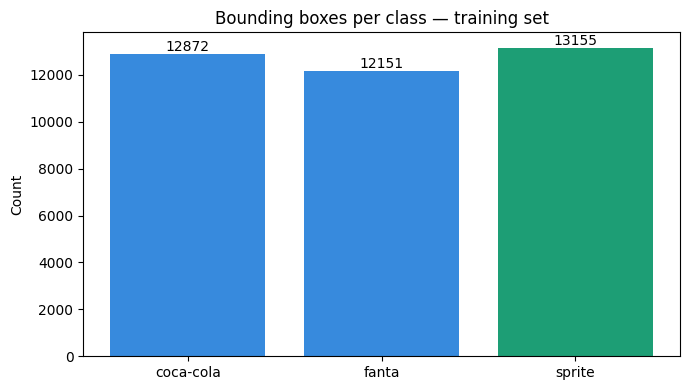


Balance OK: Ratio 1.1:1 — dataset is reasonably balanced.


In [28]:
# Count bounding box labels per class
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

class_names = cfg.get("names", [])
print("Classes:", class_names)

# Count labels in training set
train_labels = Path(DATA_YAML).parent / "train" / "labels"
class_counts = {i: 0 for i in range(len(class_names))}

if train_labels.exists():
    for label_file in train_labels.glob("*.txt"):
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_counts[int(parts[0])] += 1

print("\nBounding boxes per class (training set):")
for cls_id, count in class_counts.items():
    name = class_names[cls_id] if cls_id < len(class_names) else f"class_{cls_id}"
    print(f"  {name:<20}: {count:,}")

total = sum(class_counts.values())
if total > 0:
    print("\nClass balance:")
    for cls_id, count in class_counts.items():
        name = class_names[cls_id] if cls_id < len(class_names) else f"class_{cls_id}"
        pct = count / total * 100
        bar = "#" * int(pct / 2)
        flag = "  <-- WARNING: imbalanced" if pct < 25 or pct > 75 else ""
        print(f"  {name:<20}: {pct:5.1f}%  {bar}{flag}")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
names = [class_names[i] if i < len(class_names) else f"class_{i}"
         for i in class_counts]
counts = list(class_counts.values())
colors = ["#1D9E75" if c == max(counts) else "#378ADD" for c in counts]
ax.bar(names, counts, color=colors)
ax.set_title("Bounding boxes per class — training set")
ax.set_ylabel("Count")
for i, c in enumerate(counts):
    ax.text(i, c + max(counts)*0.01, str(c), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

if max(counts) > 0 and min(counts) > 0:
    ratio = max(counts) / min(counts)
    if ratio > 2:
        print(f"\nIMBALANCE WARNING: Ratio {ratio:.1f}:1 — consider adding more images of the minority class.")
    else:
        print(f"\nBalance OK: Ratio {ratio:.1f}:1 — dataset is reasonably balanced.")

### Step 6 — Preview sample images from the dataset

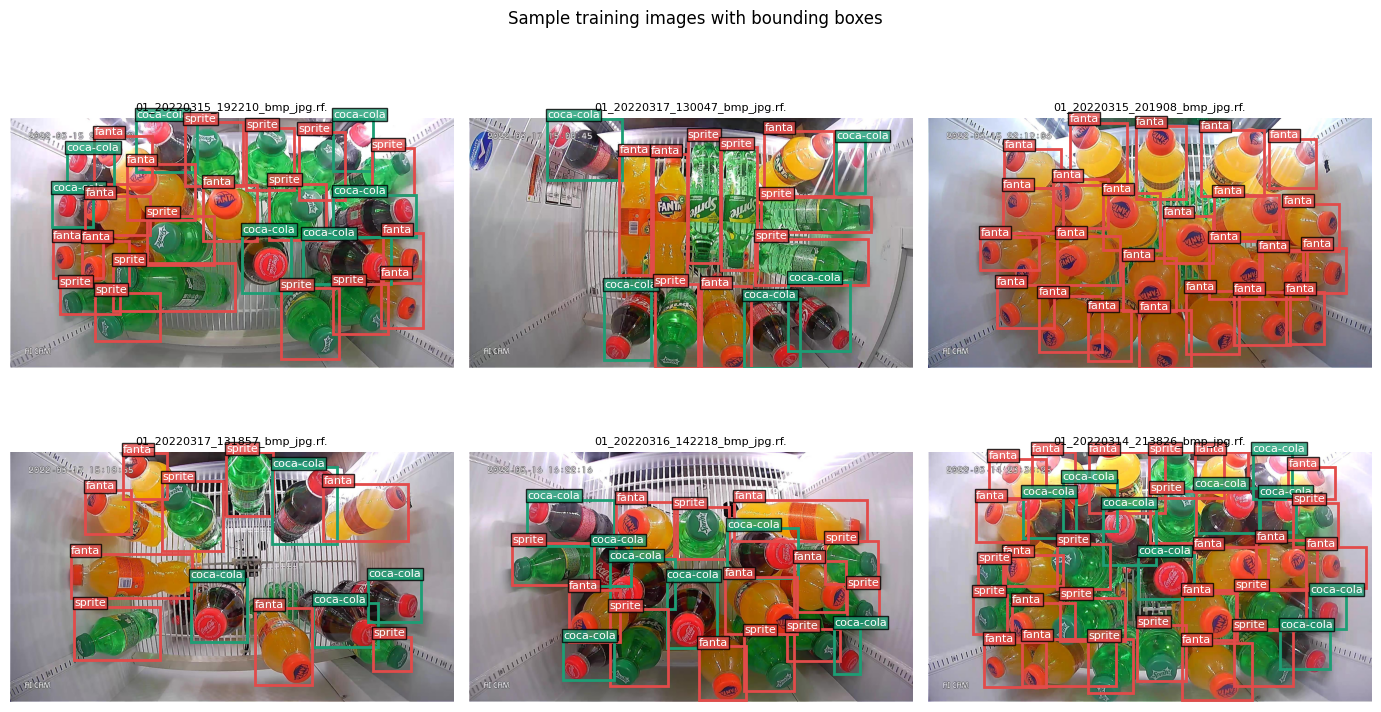

In [29]:
# Show a few training images with their bounding box labels
train_images = list((Path(DATA_YAML).parent / "train" / "images").glob("*.jpg"))
if not train_images:
    train_images = list((Path(DATA_YAML).parent / "train" / "images").glob("*.png"))

sample = train_images[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, img_path in enumerate(sample):
    img = Image.open(img_path)
    w, h = img.size
    ax = axes[i]
    ax.imshow(img)

    # Draw bounding boxes from label file
    label_path = img_path.parent.parent / "labels" / (img_path.stem + ".txt")
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    x1 = (cx - bw/2) * w
                    y1 = (cy - bh/2) * h
                    color = "#1D9E75" if cls == 0 else "#E24B4A"
                    name = class_names[cls] if cls < len(class_names) else f"cls{cls}"
                    rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                             linewidth=2, edgecolor=color, facecolor="none")
                    ax.add_patch(rect)
                    ax.text(x1, y1-4, name, color="white", fontsize=8,
                            bbox=dict(facecolor=color, alpha=0.8, pad=1))
    ax.axis("off")
    ax.set_title(img_path.name[:30], fontsize=8)

plt.suptitle("Sample training images with bounding boxes", fontsize=12)
plt.tight_layout()
plt.show()

---
## Phase 3 — Train YOLOv8n & Augmentation (Model 3)

> This is Saad's assigned model. YOLOv8n = nano version & Augmentation
> Training takes approximately **20–40 minutes** on a T4 GPU. Do not close the browser tab.

### Step 7 — Define training settings

In [30]:
# Training hyperparameters
MODEL_WEIGHTS = "yolov8n.pt"
EPOCHS        = 50
IMAGE_SIZE    = 640
BATCH_SIZE    = 16
LR            = 0.01
PROJECT_NAME  = "ShelfSight"
RUN_NAME      = "YOLOv8n_Model_&_Augmentation"

print("Training settings:")
print(f"  Model       : {MODEL_WEIGHTS}")
print(f"  Epochs      : {EPOCHS}")
print(f"  Image size  : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Batch size  : {BATCH_SIZE}")
print(f"  Learning rate: {LR}")
print(f"  Output name : {PROJECT_NAME}/{RUN_NAME}")

Training settings:
  Model       : yolov8n.pt
  Epochs      : 50
  Image size  : 640x640
  Batch size  : 16
  Learning rate: 0.01
  Output name : ShelfSight/YOLOv8n_Model_&_Augmentation


### Step 8 — Load the pre-trained YOLOv8n model
This downloads the pre-trained weights from the internet (~6MB). The model already knows how to detect general objects — we just teach it to recognise shelf products.

In [31]:
model = YOLO(MODEL_WEIGHTS)
print(f"Model loaded: {MODEL_WEIGHTS}")
print(f"Parameters  : {sum(p.numel() for p in model.model.parameters()):,}")

Model loaded: yolov8n.pt
Parameters  : 3,157,200


### Step 9 — Train the model
This is the main training step. Watch the mAP50 column — it should rise each epoch.

In [32]:
results = model.train(
    data      = DATA_YAML,
    epochs    = EPOCHS,
    imgsz     = IMAGE_SIZE,
    batch     = BATCH_SIZE,
    lr0       = LR,
    project   = PROJECT_NAME,
    name      = "YOLOv8n_Augmented",
    patience  = 10,
    save      = True,
    plots     = True,
    verbose   = True,

      # ===== AUGMENTATION PARAMETERS  =====
    hsv_h     = 0.015,    # Hue augmentation (0-1)
    hsv_s     = 0.7,      # Saturation augmentation
    hsv_v     = 0.4,      # Value (brightness) augmentation
    degrees   = 5.0,      # Random rotation (±5 degrees)
    translate = 0.1,      # Random translation (±10%)
    scale     = 0.5,      # Random scaling (50% zoom variation)
    fliplr    = 0.5,      # Horizontal flip probability
    flipud    = 0.0,      # Vertical flip (0 = off, shelves upright)
    mosaic    = 1.0,      # Mosaic augmentation (combine 4 images)
    mixup     = 0.0,      # Mixup (optional, keep 0)
    copy_paste = 0.0,     # Copy-paste augmentation

)

print("\n✅ Training with AUGMENTATION complete!")
print(f"Augmentations used: HSV, rotation, translation, scaling, fliplr, mosaic")
print(f"Best model saved at: {PROJECT_NAME}/YOLOv8n_Augmented/weights/best.pt")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=soda-bottles-haga-1/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_Augmented-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

---
## Phase 4 — Evaluate the Model

> Run these cells after training finishes to measure how well your model performs.

### Step 10 — Load the best trained model

In [33]:
from ultralytics import YOLO
from pathlib import Path

# The model saved in /content/runs/detect/ShelfSight/YOLOv8n_Augmented/
# NOT just /content/ShelfSight/

BEST_MODEL = "/content/runs/detect/ShelfSight/YOLOv8n_Augmented/weights/best.pt"

# Verify it exists
if Path(BEST_MODEL).exists():
    trained_model = YOLO(BEST_MODEL)
    print(f"✅ Model loaded successfully!")
    print(f"   Path: {BEST_MODEL}")
    print(f"   Classes: {trained_model.names}")

    # Optional: Print model info
    print(f"\n📊 Model Info:")
    print(f"   Type: YOLOv8n with Augmentation")
    print(f"   Input size: 640x640")
else:
    print(f"❌ Model not found at: {BEST_MODEL}")
    print("   Searching for best.pt anywhere...")

    # Fallback search
    all_models = list(Path("/content").rglob("best.pt"))
    if all_models:
        trained_model = YOLO(str(all_models[0]))
        print(f"✅ Found and loaded: {all_models[0]}")
    else:
        print("❌ No model found!")

✅ Model loaded successfully!
   Path: /content/runs/detect/ShelfSight/YOLOv8n_Augmented/weights/best.pt
   Classes: {0: 'coca-cola', 1: 'fanta', 2: 'sprite'}

📊 Model Info:
   Type: YOLOv8n with Augmentation
   Input size: 640x640


### Step 11 — Evaluate on the test set
This runs the model on images it has never seen before and reports accuracy.

In [34]:
metrics = trained_model.val(
    data    = DATA_YAML,
    split   = "test",     # evaluate on test set (not train or val)
    imgsz   = IMAGE_SIZE,
    verbose = True,
)

# Extract key metrics
map50    = metrics.box.map50
map5095  = metrics.box.map
precision = metrics.box.mp
recall    = metrics.box.mr

print("\n" + "="*50)
print("MODEL 3 (YOLOv8n) & Augmentation — FINAL RESULTS")
print("="*50)
print(f"  mAP50         : {map50*100:.2f}%  (main score — aim for >50%)")
print(f"  mAP50-95      : {map5095*100:.2f}%  (stricter score)")
print(f"  Precision     : {precision*100:.2f}%  (of detections made, how many correct)")
print(f"  Recall        : {recall*100:.2f}%  (of real products, how many found)")
print("="*50)

# Grading guide
if map50 >= 0.70:
    grade = "Excellent"
elif map50 >= 0.50:
    grade = "Good"
elif map50 >= 0.30:
    grade = "Decent"
else:
    grade = "Needs improvement — add more images"
print(f"  Grade         : {grade}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3086.9±721.1 MB/s, size: 264.7 KB)
val: Scanning /content/soda-bottles-haga-1/test/labels.cache... 226 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 226/226 67.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.5it/s 10.0s
                   all        226       5555      0.941      0.929      0.951      0.538
             coca-cola        220       1829      0.947      0.911      0.947      0.532
                 fanta        223       1832       0.95      0.939      0.958      0.539
                sprite        219       1894      0.926      0.938      0.947      0.544
Speed: 2.7ms preprocess, 4.2ms inference, 0.0ms loss, 14.1ms postprocess per image
Results saved to /content/runs/detect/val-

### Step 12 — Plot training curves
Shows how accuracy and loss changed during training — include these in your report.

Looking for results at: /content/runs/detect/ShelfSight/YOLOv8n_Augmented/results.csv


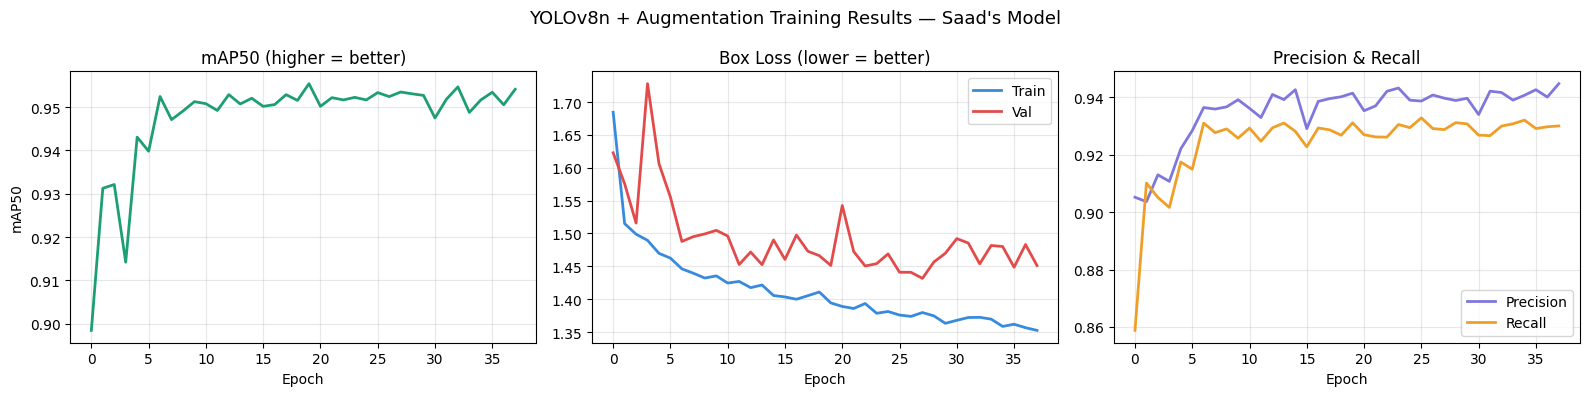

In [35]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Use the correct path where results saved
results_dir = Path("/content/runs/detect/ShelfSight/YOLOv8n_Augmented")
results_csv = results_dir / "results.csv"

print(f"Looking for results at: {results_csv}")

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # mAP50
    if "metrics/mAP50(B)" in df.columns:
        axes[0].plot(df["metrics/mAP50(B)"], color="#1D9E75", linewidth=2)
        axes[0].set_title("mAP50 (higher = better)")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("mAP50")
        axes[0].grid(alpha=0.3)

    # Box loss
    if "train/box_loss" in df.columns:
        axes[1].plot(df["train/box_loss"], label="Train", color="#378ADD", linewidth=2)
        if "val/box_loss" in df.columns:
            axes[1].plot(df["val/box_loss"], label="Val", color="#E24B4A", linewidth=2)
        axes[1].set_title("Box Loss (lower = better)")
        axes[1].set_xlabel("Epoch")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

    # Precision & Recall
    if "metrics/precision(B)" in df.columns:
        axes[2].plot(df["metrics/precision(B)"], label="Precision", color="#7F77DD", linewidth=2)
        if "metrics/recall(B)" in df.columns:
            axes[2].plot(df["metrics/recall(B)"], label="Recall", color="#EF9F27", linewidth=2)
        axes[2].set_title("Precision & Recall")
        axes[2].set_xlabel("Epoch")
        axes[2].legend()
        axes[2].grid(alpha=0.3)

    plt.suptitle("YOLOv8n + Augmentation Training Results — Saad's Model", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print(f"results.csv not found at {results_csv}")
    print("Checking alternative locations...")
    alt_files = list(Path("/content").rglob("results.csv"))
    if alt_files:
        print(f"Found at: {alt_files[0]}")

### Step 13 — Show auto-generated plots from training
YOLO saves confusion matrix and detection plots automatically.


--- confusion_matrix.png ---


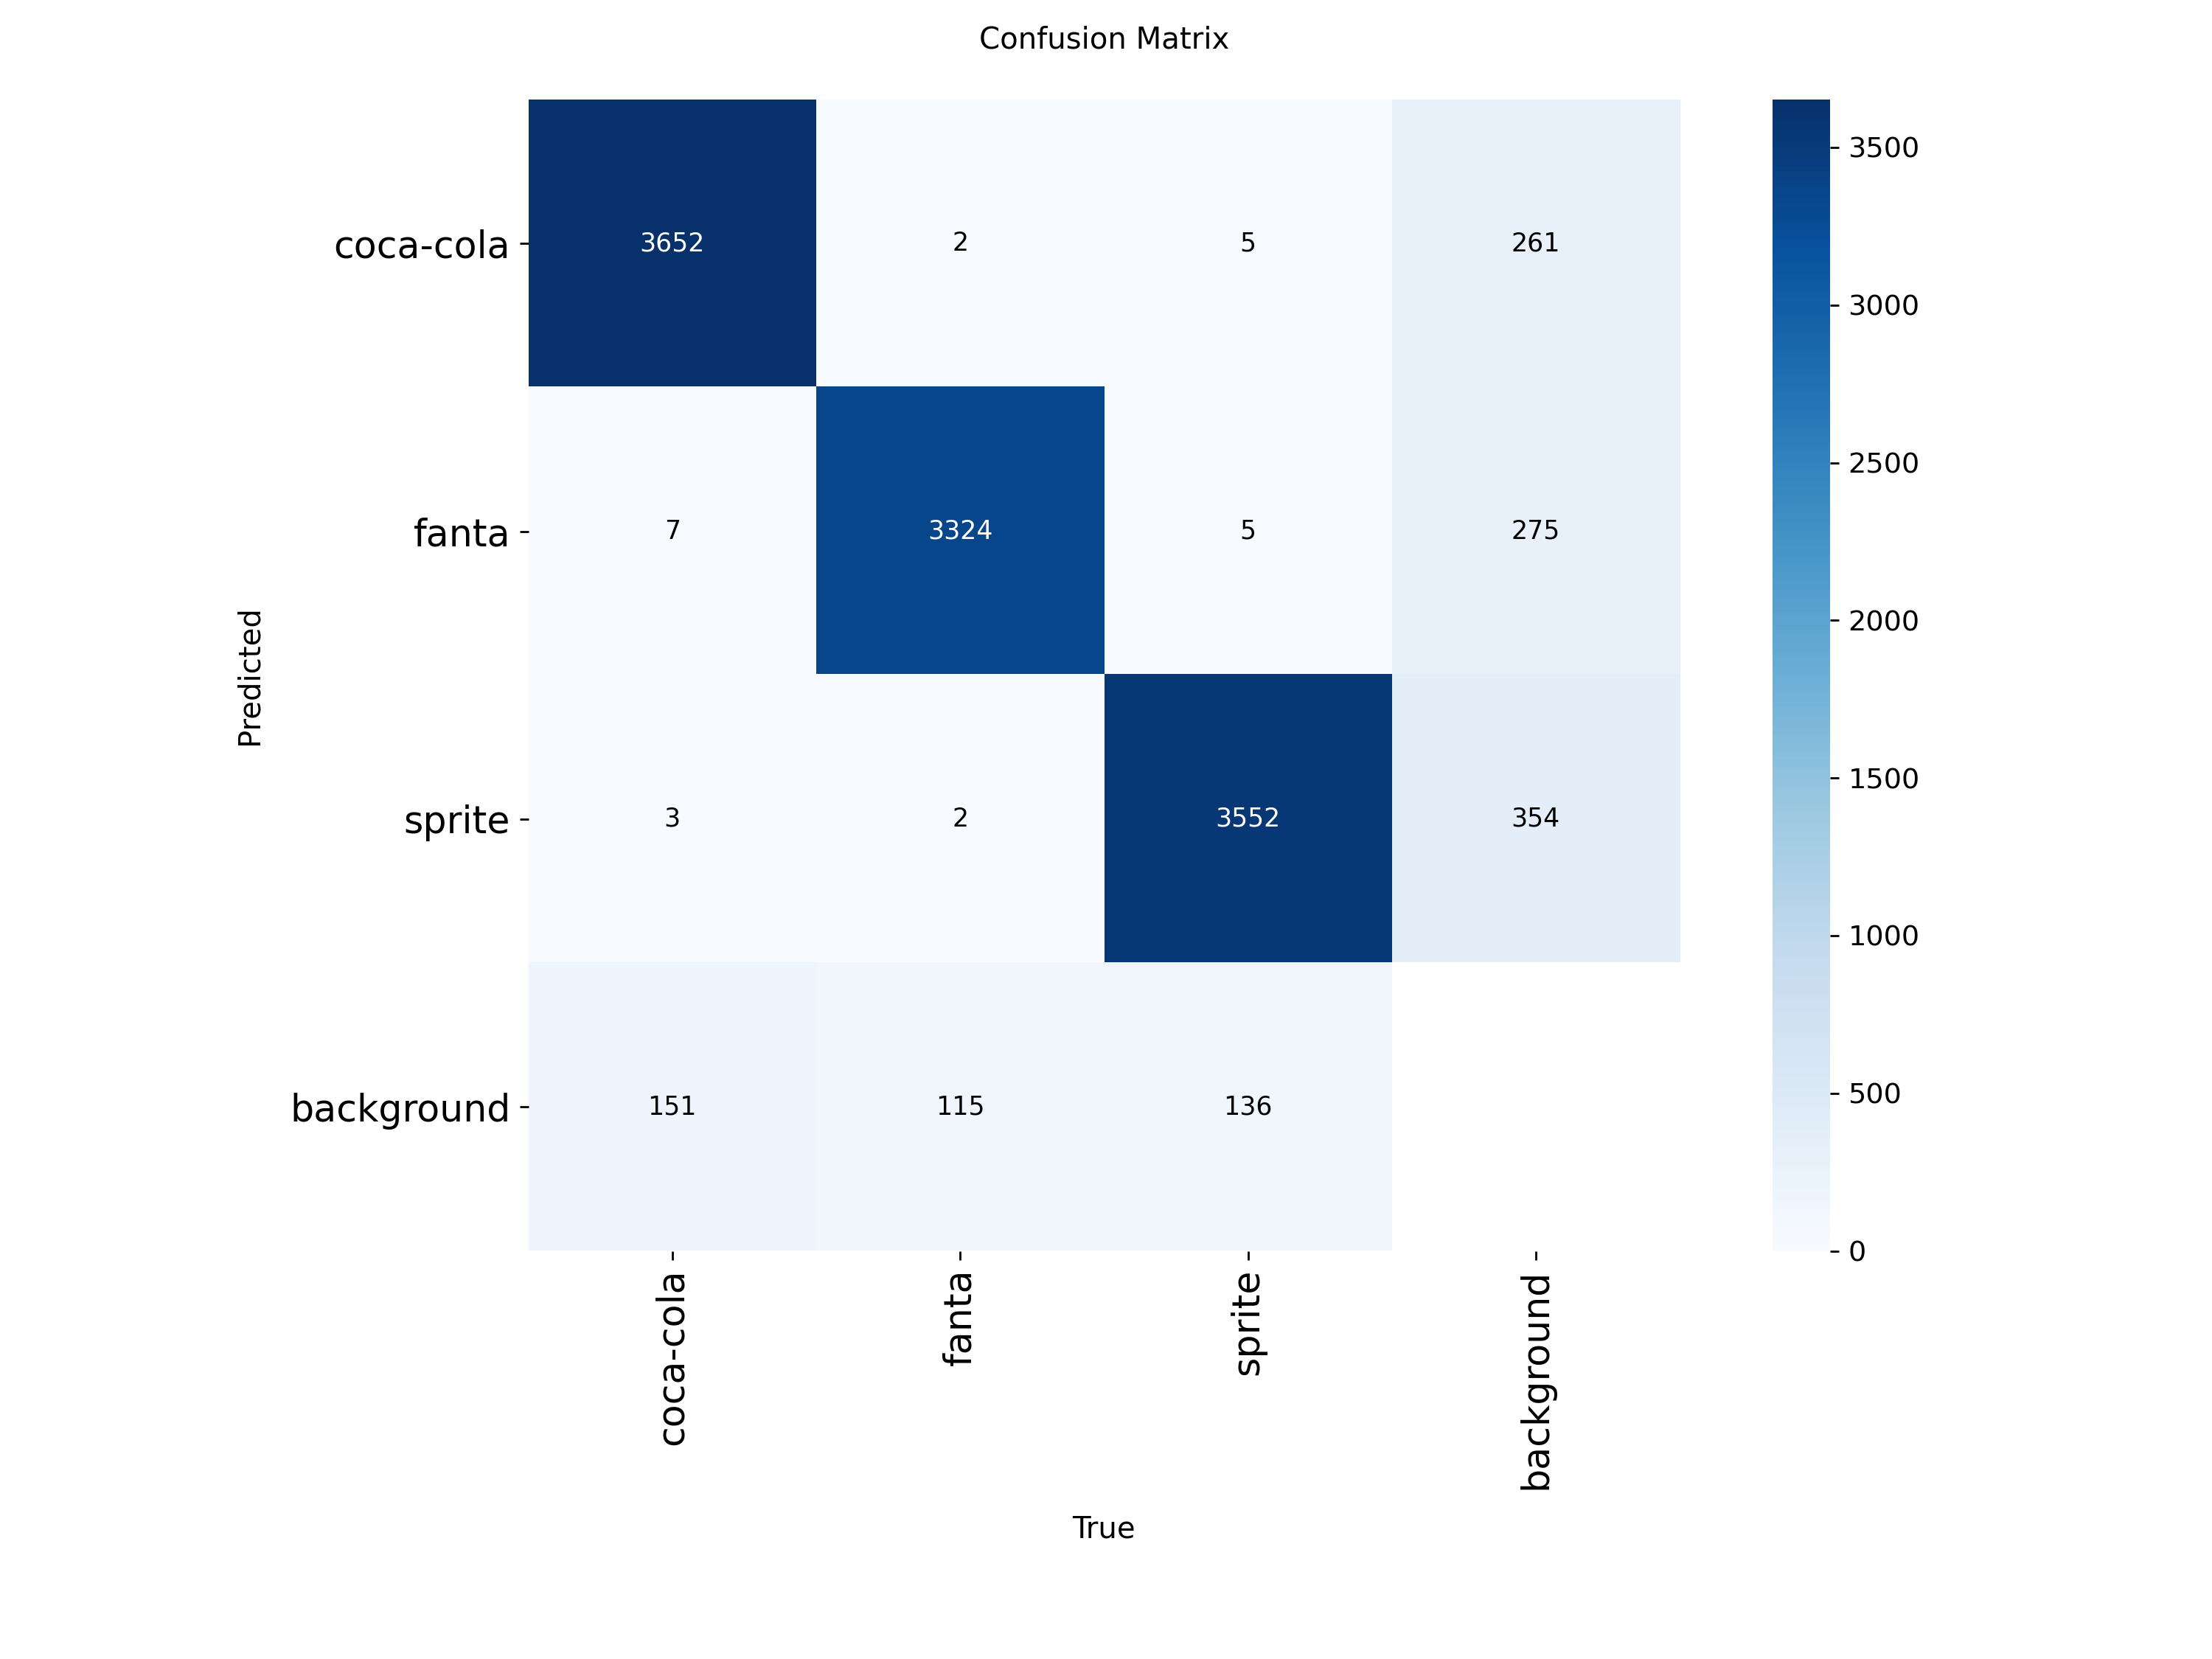


--- results.png ---


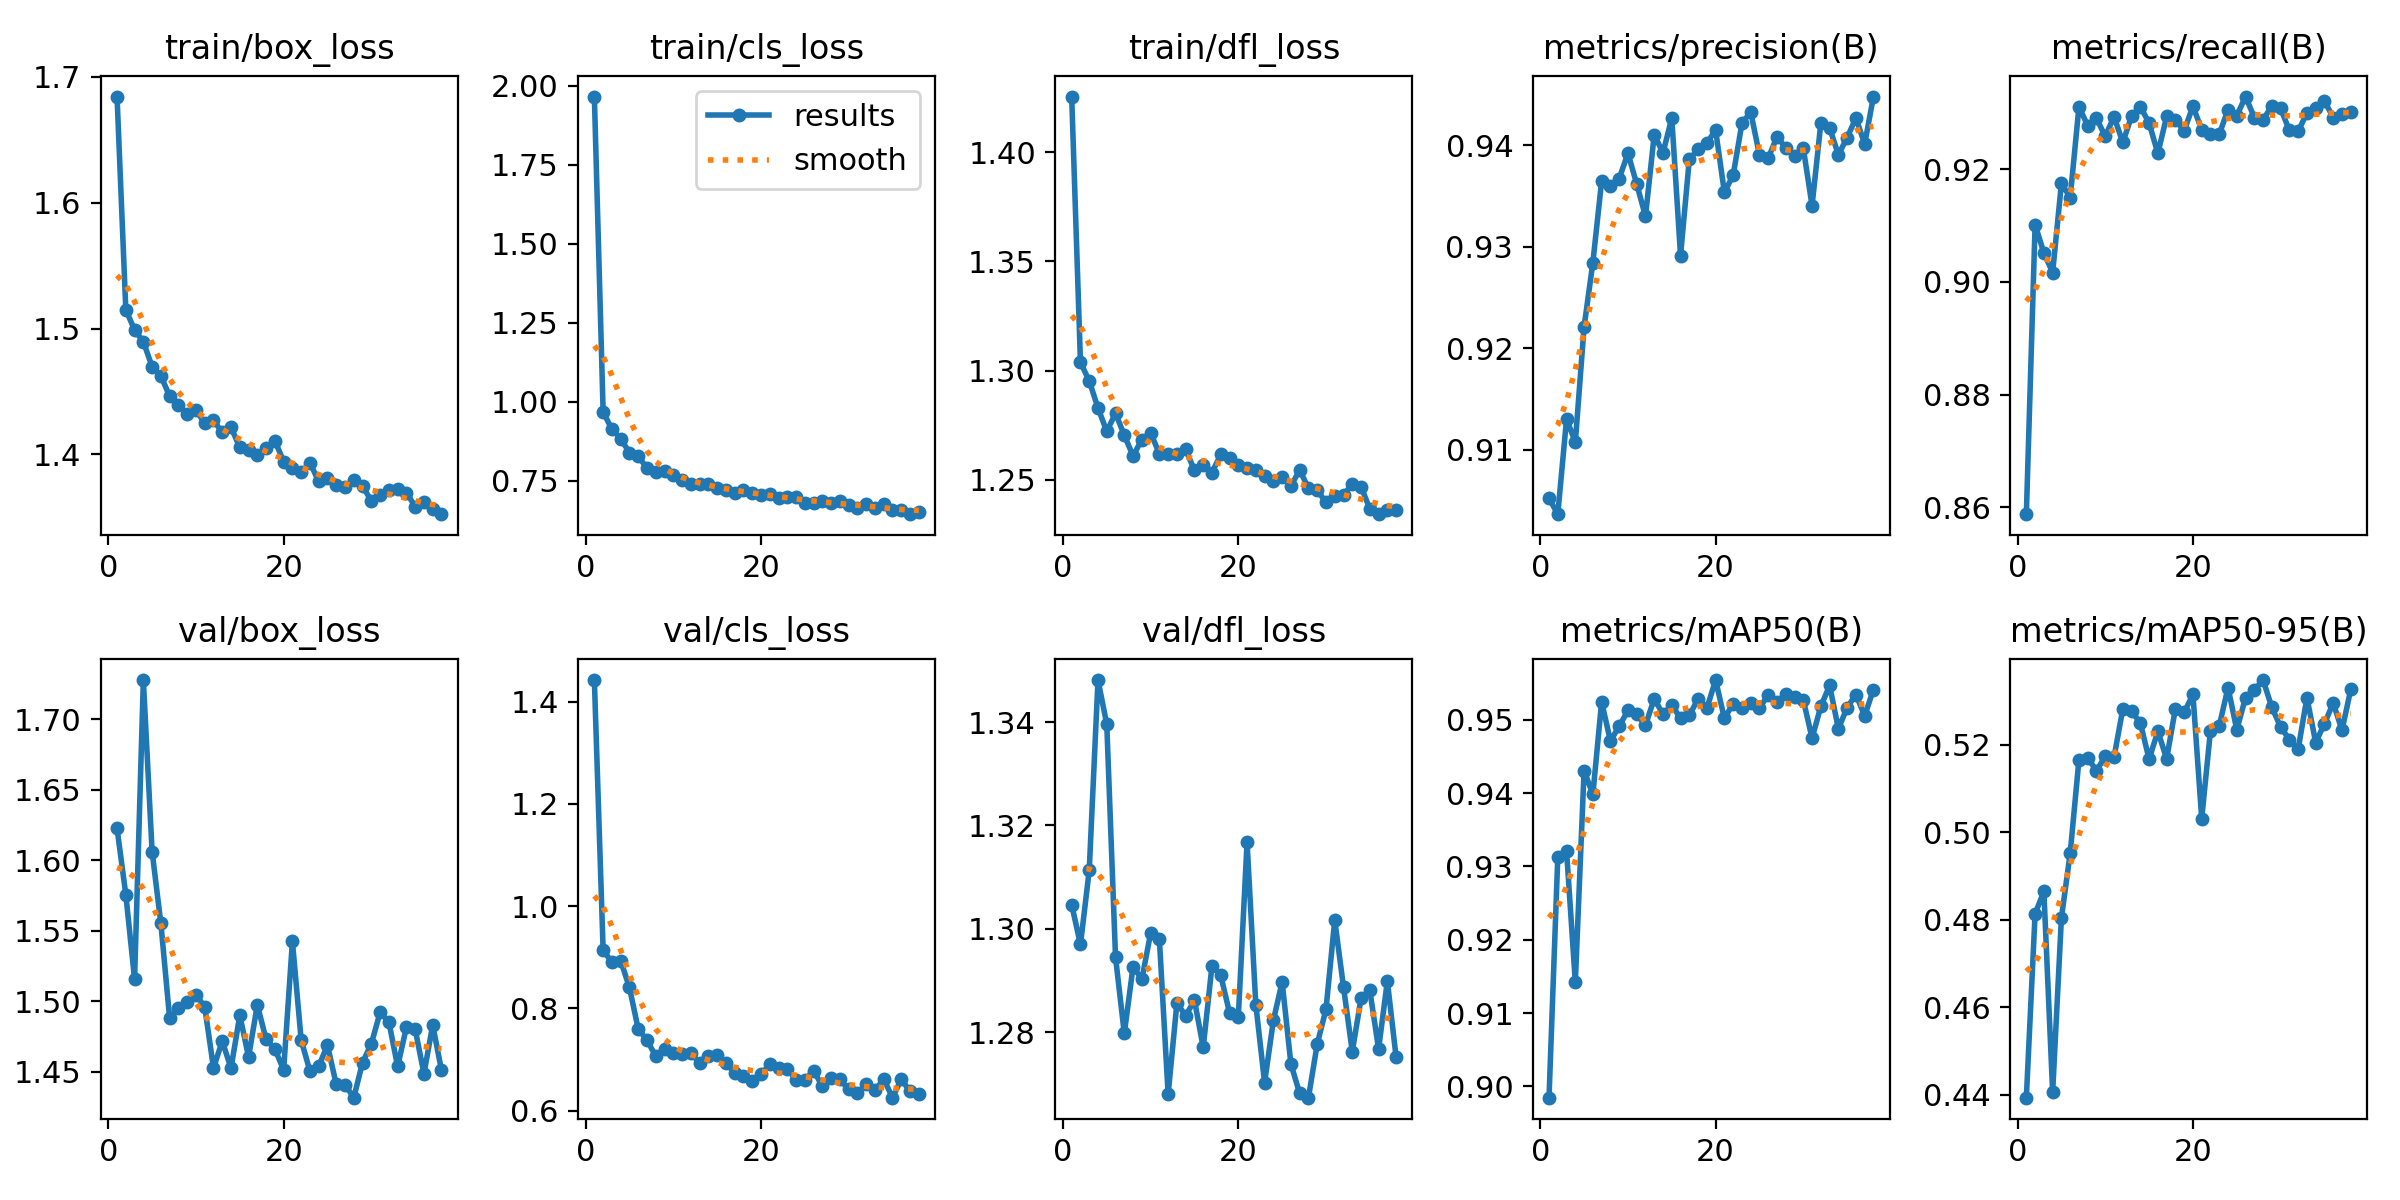

Not found: /content/runs/detect/ShelfSight/YOLOv8n_Augmented/PR_curve.png
Not found: /content/runs/detect/ShelfSight/YOLOv8n_Augmented/F1_curve.png


In [36]:


from IPython.display import Image as IPImage, display
from pathlib import Path

# Use the correct base path
base_path = Path("/content/runs/detect/ShelfSight/YOLOv8n_Augmented")

plot_files = [
    base_path / "confusion_matrix.png",
    base_path / "results.png",
    base_path / "PR_curve.png",
    base_path / "F1_curve.png",
]

for plot in plot_files:
    if plot.exists():
        print(f"\n--- {plot.name} ---")
        display(IPImage(str(plot), width=700))
    else:
        print(f"Not found: {plot}")

---
## Phase 5 — Test on New Images

> Upload a shelf photo and see the model detect products in real time.

### Step 14 — Run detection on a test image
Upload any shelf photo to Colab (click the folder icon on the left → upload), then run this cell.

In [37]:
# Change this to the filename of the image you uploaded
TEST_IMAGE = "sampletest.jpeg"   # <-- UPDATE THIS

if not Path(TEST_IMAGE).exists():
    print(f"File '{TEST_IMAGE}' not found.")
    print("Upload a shelf photo to Colab first (folder icon on left sidebar → upload)")
else:
    detect_results = trained_model.predict(
        source     = sampletest.jpeg,
        conf       = 0.5,     # only show detections with >50% confidence
        save       = True,
        save_txt   = True,
        project    = "detections",
        name       = "test1",
    )

    # Show the result image
    output_imgs = list(Path("detections/test1").glob("*.jpg"))
    if not output_imgs:
        output_imgs = list(Path("detections/test1").glob("*.png"))

    if output_imgs:
        display(IPImage(str(output_imgs[0]), width=700))

    # Print detection summary
    result = detect_results[0]
    print(f"\nDetected {len(result.boxes)} objects:")
    for box in result.boxes:
        cls_id = int(box.cls)
        conf   = float(box.conf)
        name   = trained_model.names[cls_id]
        print(f"  {name:<20} confidence: {conf*100:.1f}%")

File 'sampletest.jpeg' not found.
Upload a shelf photo to Colab first (folder icon on left sidebar → upload)


In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 15 — Calculate shelf metrics from detections

In [46]:
# Run this after Step 14 to calculate SOS, OSA, and Compliance

if Path(TEST_IMAGE).exists():
    result = detect_results[0]
    boxes  = result.boxes

    if len(boxes) == 0:
        print("No products detected. Try lowering conf to 0.3 in Step 14.")
    else:
        # Count detections per class
        class_counts = {}
        for box in boxes:
            cls_id = int(box.cls)
            name   = trained_model.names[cls_id]
            class_counts[name] = class_counts.get(name, 0) + 1

        total = sum(class_counts.values())

        print("Detection counts:")
        for name, count in class_counts.items():
            print(f"  {name:<20}: {count}")

        # Share of Shelf (SOS)
        nestle_key = next((k for k in class_counts if "nestle" in k.lower()), None)
        if nestle_key:
            sos = class_counts[nestle_key] / total * 100
            print(f"\nShare of Shelf (SOS)  : {sos:.1f}%")
            print(f"  Nestle products      : {class_counts[nestle_key]}")
            print(f"  Competitor products  : {total - class_counts[nestle_key]}")
        else:
            print("\nNote: No 'nestle' class found — update class name to match your dataset.")

        # On-Shelf Availability (OSA) — proxy: detections vs expected slots
        print(f"\nTotal detected products: {total}")
        print("On-Shelf Availability  : products are present (OSA check requires planogram reference)")

        print("\nPlanogram Compliance   : manual check required (compare detected positions vs planogram)")

---
## Phase 6 — Save and Download

> **CRITICAL: Download your model immediately. Colab deletes files after a few hours of inactivity.**

### Step 16 — Download the trained model

In [40]:
from google.colab import files
from pathlib import Path

# Correct path to best.pt
best_pt = "/content/runs/detect/ShelfSight/YOLOv8n_Augmented/weights/best.pt"

if Path(best_pt).exists():
    files.download(best_pt)
    print(f"✅ best.pt downloaded from: {best_pt}")
    file_size = Path(best_pt).stat().st_size / (1024 * 1024)
    print(f"   File size: {file_size:.1f} MB")
else:
    print(f"❌ best.pt not found at {best_pt}")

    # Search fallback
    found = list(Path("/content").rglob("best.pt"))
    if found:
        files.download(str(found[0]))
        print(f"✅ Downloaded from: {found[0]}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ best.pt downloaded from: /content/runs/detect/ShelfSight/YOLOv8n_Augmented/weights/best.pt
   File size: 5.9 MB


### Step 17 — Download all training plots and results

In [43]:
# ─── DOWNLOAD MODEL + ALL RESULTS ────────────────────────────────────────────
import zipfile, torch
from pathlib import Path
from ultralytics import YOLO
from google.colab import files

run_dir     = Path("/content/runs/detect/ShelfSight/YOLOv8n_Augmented")
weights_dir = run_dir / "weights"
best_pt     = weights_dir / "best.pt"

# ── 1. Verify the model actually works (inference test) ──────────────────────
print("=== Verifying model ===")
if not best_pt.exists():
    found = list(Path("/content").rglob("best.pt"))
    best_pt = found[0] if found else None

if best_pt:
    model = YOLO(str(best_pt))
    print(f"✅ Model loads OK")
    print(f"   Classes : {model.names}")
    print(f"   Size    : {best_pt.stat().st_size / 1e6:.1f} MB")
else:
    print("❌ best.pt not found anywhere — did training finish?")
    raise FileNotFoundError("No best.pt found")

# ── 2. Print the actual metrics ───────────────────────────────────────────────
print("\n=== Training Metrics ===")
ck = torch.load(str(best_pt), map_location="cpu", weights_only=False)
m  = ck.get("train_metrics", {})
if m:
    print(f"  mAP50      : {m.get('metrics/mAP50(B)',    0)*100:.2f}%")
    print(f"  mAP50-95   : {m.get('metrics/mAP50-95(B)', 0)*100:.2f}%")
    print(f"  Precision  : {m.get('metrics/precision(B)',0)*100:.2f}%")
    print(f"  Recall     : {m.get('metrics/recall(B)',   0)*100:.2f}%")
else:
    print("  (metrics not stored in checkpoint)")

# ── 3. Download best.pt ───────────────────────────────────────────────────────
print("\n=== Downloading best.pt ===")
files.download(str(best_pt))
print(f"✅ best.pt downloaded ({best_pt.stat().st_size/1e6:.1f} MB)")

# ── 4. Zip and download all results (plots, curves, csv) ─────────────────────
print("\n=== Zipping results ===")
zip_path = Path("/content/ShelfSight_YOLOv8n_Augmented_Results.zip")

all_files = [f for f in run_dir.rglob("*") if f.is_file() and f.suffix != ".pt"]
print(f"Files to zip: {len(all_files)}")

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in all_files:
        arcname = f.relative_to(run_dir)
        zf.write(f, arcname)
        print(f"  + {arcname}")

print(f"\n✅ Zip ready: {zip_path.stat().st_size/1e6:.1f} MB")
files.download(str(zip_path))
print("✅ Results zip downloaded")

=== Verifying model ===
✅ Model loads OK
   Classes : {0: 'coca-cola', 1: 'fanta', 2: 'sprite'}
   Size    : 6.2 MB

=== Training Metrics ===
  mAP50      : 95.35%
  mAP50-95   : 53.48%
  Precision  : 93.97%
  Recall     : 92.88%

=== Downloading best.pt ===


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ best.pt downloaded (6.2 MB)

=== Zipping results ===
Files to zip: 19
  + confusion_matrix_normalized.png
  + results.png
  + val_batch1_labels.jpg
  + val_batch0_labels.jpg
  + train_batch2.jpg
  + train_batch1.jpg
  + args.yaml
  + val_batch0_pred.jpg
  + BoxF1_curve.png
  + BoxP_curve.png
  + BoxR_curve.png
  + val_batch1_pred.jpg
  + val_batch2_pred.jpg
  + results.csv
  + train_batch0.jpg
  + labels.jpg
  + val_batch2_labels.jpg
  + BoxPR_curve.png
  + confusion_matrix.png

✅ Zip ready: 7.8 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Results zip downloaded


### Step 18 — Print final summary for the report

In [47]:
print("=" * 55)
print("SAAD — MODEL 3 FINAL SUMMARY")
print("=" * 55)
print(f"Model architecture : YOLOv8n(nano) & Augmentation")
print(f"Dataset            : Roboflow export (YOLOv8 format)")
print(f"Image size         : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Epochs             : {EPOCHS} (with early stopping)")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Learning rate      : {LR}")
print("-" * 55)
print(f"mAP50              : {map50*100:.2f}%")
print(f"mAP50-95           : {map5095*100:.2f}%")
print(f"Precision          : {precision*100:.2f}%")
print(f"Recall             : {recall*100:.2f}%")
print("-" * 55)
print("Files saved:")
print(f"  best.pt          : {BEST_MODEL}")
print(f"  Results folder   : {PROJECT_NAME}/{RUN_NAME}/")
print("=" * 55)
print("\nRecord these numbers in the group comparison table.")

SAAD — MODEL 3 FINAL SUMMARY
Model architecture : YOLOv8n(nano) & Augmentation
Dataset            : Roboflow export (YOLOv8 format)
Image size         : 640x640
Epochs             : 50 (with early stopping)
Batch size         : 16
Learning rate      : 0.01
-------------------------------------------------------
mAP50              : 95.06%
mAP50-95           : 53.82%
Precision          : 94.09%
Recall             : 92.91%
-------------------------------------------------------
Files saved:
  best.pt          : /content/runs/detect/ShelfSight/YOLOv8n_Augmented/weights/best.pt
  Results folder   : ShelfSight/YOLOv8n_Model_&_Augmentation/

Record these numbers in the group comparison table.
